# **Ejercicio Binning, Imputación, Outliers, Dummies, etc.**
El siguiente Dataset contiene detalles de 1000 potenciales compradores de bicicletas, realizaremos un análisis exploratorio del mismo, imputando las variables que correspondan.

In [1100]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
bike_buyers = pd.read_csv('https://raw.githubusercontent.com/pokengineer/DataScience/main/datasets/bike_buyers.csv')

## **Dataset**

In [1101]:
bike_buyers.describe(include='all')

,ID,Marital Status,Gender,Income,Children,Education,Occupation,Home Owner,Cars,Commute Distance,Region,Age,Purchased Bike
count,1000.000000,993,989,994.000000,992.000000,1000,1000,996,991.000000,1000,1000,993.000000,1000
unique,NaN,2,2,NaN,NaN,5,5,2,NaN,5,3,NaN,2
top,NaN,Married,Male,NaN,NaN,Bachelors,Professional,Yes,NaN,0-1 Miles,North America,NaN,No
freq,NaN,535,500,NaN,NaN,306,276,682,NaN,366,508,NaN,519
mean,19965.992000,NaN,NaN,56267.605634,1.910282,NaN,NaN,NaN,1.455096,NaN,NaN,44.139980,NaN
std,5347.333948,NaN,NaN,31067.817462,1.626910,NaN,NaN,NaN,1.121755,NaN,NaN,12.338209,NaN
min,11000.000000,NaN,NaN,10000.000000,0.000000,NaN,NaN,NaN,0.000000,NaN,NaN,-28.000000,NaN
25%,15290.750000,NaN,NaN,30000.000000,0.000000,NaN,NaN,NaN,1.000000,NaN,NaN,35.000000,NaN
50%,19744.000000,NaN,NaN,60000.000000,2.000000,NaN,NaN,NaN,1.000000,NaN,NaN,43.000000,NaN
75%,24470.750000,NaN,NaN,70000.000000,3.000000,NaN,NaN,NaN,2.000000,NaN,NaN,52.000000,NaN


In [1102]:
bike_buyers.dtypes

ID                    int64
Marital Status       object
Gender               object
Income              float64
Children            float64
Education            object
Occupation           object
Home Owner           object
Cars                float64
Commute Distance     object
Region               object
Age                 float64
Purchased Bike       object
dtype: object

In [1103]:
bike_buyers.head()

,ID,Marital Status,Gender,Income,Children,Education,Occupation,Home Owner,Cars,Commute Distance,Region,Age,Purchased Bike
0,12496,Married,Female,40000.0,1.0,Bachelors,Skilled Manual,Yes,0.0,0-1 Miles,Europe,42.0,No
1,24107,Married,Male,30000.0,3.0,Partial College,Clerical,Yes,1.0,0-1 Miles,Europe,43.0,No
2,14177,Married,Male,80000.0,5.0,Partial College,Professional,No,2.0,2-5 Miles,Europe,60.0,No
3,24381,Single,NaN,70000.0,0.0,Bachelors,Professional,Yes,1.0,5-10 Miles,Pacific,41.0,Yes
4,25597,Single,Male,30000.0,0.0,Bachelors,Clerical,No,0.0,0-1 Miles,Europe,36.0,Yes


---
## **Ejercicio 1**

¿Cuáles de las variables contienen valores nulos?

In [1104]:
print("Valores nulos por columna:")
valores_nulos = bike_buyers.isnull().sum()
valores_nulos = valores_nulos[valores_nulos > 0].sort_values(ascending=False)
print(valores_nulos)

Valores nulos por columna:
Gender            11
Cars               9
Children           8
Age                7
Marital Status     7
Income             6
Home Owner         4
dtype: int64


In [1105]:
total_filas = len(bike_buyers)
print(f"\nTotal de filas: {total_filas}")


Total de filas: 1000


Porcentaje de valores nulos por columna

In [1106]:
print((valores_nulos / total_filas * 100).round(2))

Gender            1.1
Cars              0.9
Children          0.8
Age               0.7
Marital Status    0.7
Income            0.6
Home Owner        0.4
dtype: float64


---
## **Ejercicio 2**

¿Está Balanceada la variable target 'Purchased Bike'?

In [1107]:
target_counts = bike_buyers['Purchased Bike'].value_counts()
target_percentages = bike_buyers['Purchased Bike'].value_counts(normalize=True) * 100

print("Distribución de la variable target 'Purchased Bike'")
print(target_counts)

Distribución de la variable target 'Purchased Bike'
Purchased Bike
No     519
Yes    481
Name: count, dtype: int64


Porcentajes

In [1108]:
for value, count in target_counts.items():
    print(f"{value}: {target_percentages[value]:.2f}%")

No: 51.90%
Yes: 48.10%


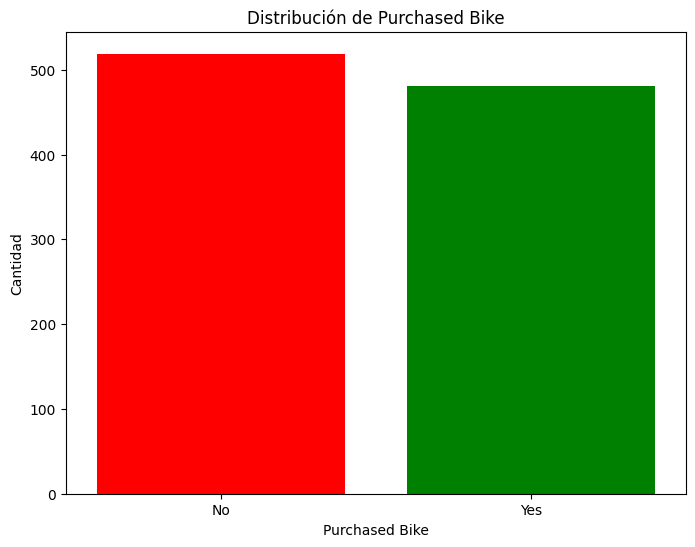

In [1109]:
plt.figure(figsize=(8, 6))
target_counts.plot(kind='bar')
plt.bar(target_counts.index, target_counts.values, color=['red', 'green'])
plt.title('Distribución de Purchased Bike')
plt.xlabel('Purchased Bike')
plt.ylabel('Cantidad')
plt.xticks(rotation=0)
plt.show()

---
## **Ejercicio 3**

Imputar los valores nulos de Gender con el valor 'X'.

In [1110]:
print("Valores nulos en Gender antes de imputar:", bike_buyers['Gender'].isnull().sum())

Valores nulos en Gender antes de imputar: 11


In [1111]:
bike_buyers['Gender'] = bike_buyers['Gender'].fillna('X')
print("Valores nulos en Gender después de imputar:", bike_buyers['Gender'].isnull().sum())

Valores nulos en Gender después de imputar: 0


In [1112]:
print("Distribución de Gender después de imputar:")
print(bike_buyers['Gender'].value_counts())

Distribución de Gender después de imputar:
Gender
Male      500
Female    489
X          11
Name: count, dtype: int64


---
## **Ejercicio 4**

Imputar los valores nulos y outliers de Age con la media.

In [1113]:
print("Estadísticas de Age antes de imputar:")
print(bike_buyers['Age'].describe())
print(f"Valores nulos en Age: {bike_buyers['Age'].isnull().sum()}")

Estadísticas de Age antes de imputar:
count    993.000000
mean      44.139980
std       12.338209
min      -28.000000
25%       35.000000
50%       43.000000
75%       52.000000
max      160.000000
Name: Age, dtype: float64
Valores nulos en Age: 7


Identificar outliers usando IQR

In [1114]:
Q1 = bike_buyers['Age'].quantile(0.25)
Q3 = bike_buyers['Age'].quantile(0.75)
IQR = Q3 - Q1
limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

print(f"Límites para outliers:")
print(f"Límite inferior: {limite_inferior:.2f}")
print(f"Límite superior: {limite_superior:.2f}")

Límites para outliers:
Límite inferior: 9.50
Límite superior: 77.50


Identificar outliers

In [1115]:
outliers_mask = (bike_buyers['Age'] < limite_inferior) | (bike_buyers['Age'] > limite_superior)
print(f"Cantidad de outliers: {outliers_mask.sum()}")

Cantidad de outliers: 8


Calcular media excluyendo outliers y nulos

In [1116]:
age_clean = bike_buyers['Age'][(~outliers_mask) & (~bike_buyers['Age'].isnull())]
media_age = age_clean.mean()
print(f"Media de Age (sin outliers ni nulos): {media_age:.2f}")

Media de Age (sin outliers ni nulos): 44.04


Imputar nulos y outliers con la media

In [1117]:
bike_buyers.loc[bike_buyers['Age'].isnull(), 'Age'] = media_age
bike_buyers.loc[outliers_mask, 'Age'] = media_age

print(f"Después de imputar")
print(f"Valores nulos en Age: {bike_buyers['Age'].isnull().sum()}")

Después de imputar
Valores nulos en Age: 0


In [1118]:
print("Estadísticas de Age después de imputar:")
print(bike_buyers['Age'].describe())

Estadísticas de Age después de imputar:
count    1000.00000
mean       44.04264
std        11.05624
min        25.00000
25%        35.00000
50%        43.00000
75%        51.00000
max        74.00000
Name: Age, dtype: float64


---
## **Ejercicio 5**

Eliminar los registros con valor nulo en Cars.

In [1119]:
print(f"Filas antes de eliminar nulos en Cars: {len(bike_buyers)}")
print(f"Valores nulos en Cars: {bike_buyers['Cars'].isnull().sum()}")

Filas antes de eliminar nulos en Cars: 1000
Valores nulos en Cars: 9


In [1120]:
bike_buyers = bike_buyers.dropna(subset=['Cars'])
print(f"Filas después de eliminar nulos en Cars: {len(bike_buyers)}")
print(f"Valores nulos en Cars: {bike_buyers['Cars'].isnull().sum()}")

Filas después de eliminar nulos en Cars: 991
Valores nulos en Cars: 0


---
## **Ejercicio 6**

Generar columnas dummy para las variables Education y Occupation.

Valores únicos en Education

In [1121]:
print(bike_buyers['Education'].value_counts())


Education
Bachelors              305
Partial College        262
High School            178
Graduate Degree        171
Partial High School     75
Name: count, dtype: int64


Valores únicos en Occupation

In [1122]:
print(bike_buyers['Occupation'].value_counts())

Occupation
Professional      275
Skilled Manual    252
Clerical          174
Management        172
Manual            118
Name: count, dtype: int64


Crear dummies para Education

In [1123]:
education_dummies = pd.get_dummies(bike_buyers['Education'], prefix='Education')
print(f"\nColumnas dummy para Education: {list(education_dummies.columns)}")


Columnas dummy para Education: ['Education_Bachelors', 'Education_Graduate Degree', 'Education_High School', 'Education_Partial College', 'Education_Partial High School']


Crear dummies para Occupation

In [1124]:
occupation_dummies = pd.get_dummies(bike_buyers['Occupation'], prefix='Occupation')
print(f"Columnas dummy para Occupation: {list(occupation_dummies.columns)}")

Columnas dummy para Occupation: ['Occupation_Clerical', 'Occupation_Management', 'Occupation_Manual', 'Occupation_Professional', 'Occupation_Skilled Manual']


Agregar las columnas dummy al DataFrame

In [1125]:
bike_buyers = pd.concat([bike_buyers, education_dummies, occupation_dummies], axis=1)
print(f"Nuevas dimensiones del DataFrame: {bike_buyers.shape}")

Nuevas dimensiones del DataFrame: (991, 23)


Primeras 5 columnas dummy agregadas

In [1126]:
print(bike_buyers[education_dummies.columns[:5]].head())

   Education_Bachelors  Education_Graduate Degree  Education_High School  \
0                 True                      False                  False   
1                False                      False                  False   
2                False                      False                  False   
3                 True                      False                  False   
4                 True                      False                  False   

   Education_Partial College  Education_Partial High School  
0                      False                          False  
1                       True                          False  
2                       True                          False  
3                      False                          False  
4                      False                          False  


Segundas 5 columnas dummy agregadas

In [1127]:
print(bike_buyers[occupation_dummies.columns[:5]].head())

   Occupation_Clerical  Occupation_Management  Occupation_Manual  \
0                False                  False              False   
1                 True                  False              False   
2                False                  False              False   
3                False                  False              False   
4                 True                  False              False   

   Occupation_Professional  Occupation_Skilled Manual  
0                    False                       True  
1                    False                      False  
2                     True                      False  
3                     True                      False  
4                    False                      False  


---
## **Ejercicio 7**

Definir una estrategia de imputación para las otras variables que corresponda.

In [1128]:
print("Valores nulos restantes por columna:")
nulos_restantes = bike_buyers.isnull().sum()
variables_con_nulos = nulos_restantes[nulos_restantes > 0]
print(variables_con_nulos)

Valores nulos restantes por columna:
Marital Status    7
Income            6
Children          8
Home Owner        4
dtype: int64


Estrategia de imputación para cada variable restante

In [1129]:
if len(variables_con_nulos) > 0:
    for columna in variables_con_nulos.index:
        print(f"\nAnalizando {columna}:")
        print(f"Tipo de dato: {bike_buyers[columna].dtype}")
        print(f"Valores únicos (no nulos): {bike_buyers[columna].dropna().nunique()}")
        
        if bike_buyers[columna].dtype in ['object']:
            # Variables categóricas: imputar con la moda
            moda = bike_buyers[columna].mode().iloc[0] if len(bike_buyers[columna].mode()) > 0 else 'Desconocido'
            bike_buyers[columna] = bike_buyers[columna].fillna(moda)
            print(f"Imputado con moda: {moda}")
        else:
            # Variables numéricas: imputar con mediana (más robusta a outliers)
            mediana = bike_buyers[columna].median()
            bike_buyers[columna] = bike_buyers[columna].fillna(mediana)
            print(f"Imputado con mediana: {mediana}")


Analizando Marital Status:
Tipo de dato: object
Valores únicos (no nulos): 2
Imputado con moda: Married

Analizando Income:
Tipo de dato: float64
Valores únicos (no nulos): 16
Imputado con mediana: 60000.0

Analizando Children:
Tipo de dato: float64
Valores únicos (no nulos): 6
Imputado con mediana: 2.0

Analizando Home Owner:
Tipo de dato: object
Valores únicos (no nulos): 2
Imputado con moda: Yes


Verificar que no queden valores nulos

In [1130]:
print(f"\nVerificación final - Total de valores nulos: {bike_buyers.isnull().sum().sum()}")


Verificación final - Total de valores nulos: 0


---
## **Ejercicio 8**

Finalizar el análisis exploratorio con gráficos del dataset.

### 1 - Configurar estilo

In [1131]:
plt.style.use('default')
sns.set_palette("husl")

### 2 - Distribución de variables numéricas

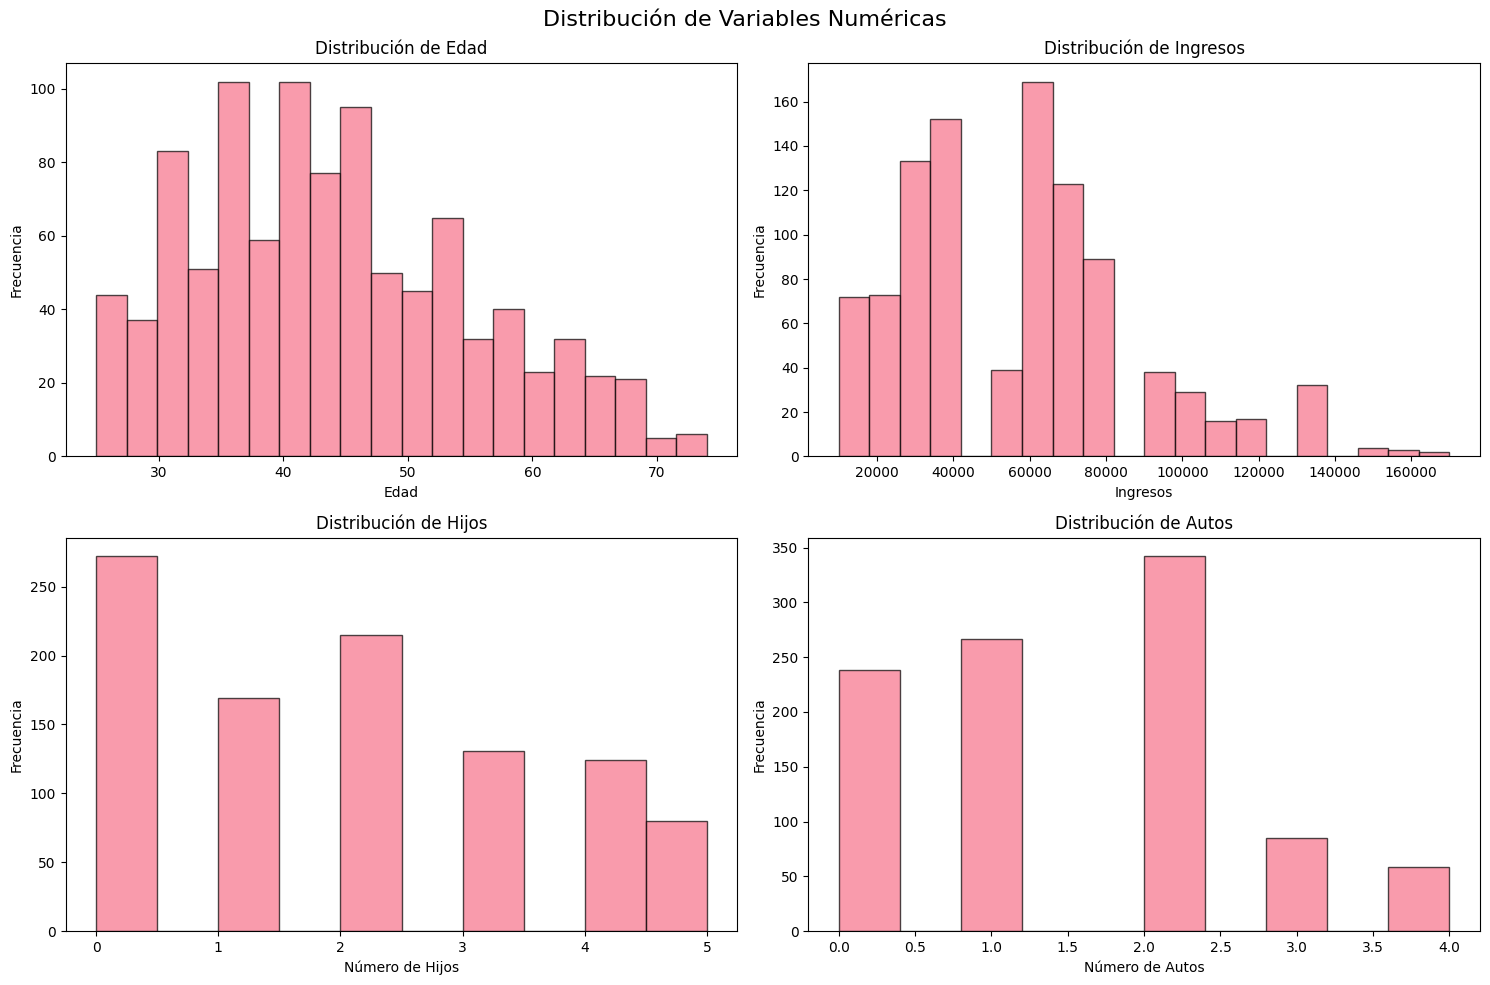

In [1132]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('Distribución de Variables Numéricas', fontsize=16)

# Age
axes[0,0].hist(bike_buyers['Age'], bins=20, alpha=0.7, edgecolor='black')
axes[0,0].set_title('Distribución de Edad')
axes[0,0].set_xlabel('Edad')
axes[0,0].set_ylabel('Frecuencia')

# Income
axes[0,1].hist(bike_buyers['Income'], bins=20, alpha=0.7, edgecolor='black')
axes[0,1].set_title('Distribución de Ingresos')
axes[0,1].set_xlabel('Ingresos')
axes[0,1].set_ylabel('Frecuencia')

# Children
axes[1,0].hist(bike_buyers['Children'], bins=10, alpha=0.7, edgecolor='black')
axes[1,0].set_title('Distribución de Hijos')
axes[1,0].set_xlabel('Número de Hijos')
axes[1,0].set_ylabel('Frecuencia')

# Cars
axes[1,1].hist(bike_buyers['Cars'], bins=10, alpha=0.7, edgecolor='black')
axes[1,1].set_title('Distribución de Autos')
axes[1,1].set_xlabel('Número de Autos')
axes[1,1].set_ylabel('Frecuencia')

plt.tight_layout()
plt.show()

### 3 - Distribución de variables categóricas

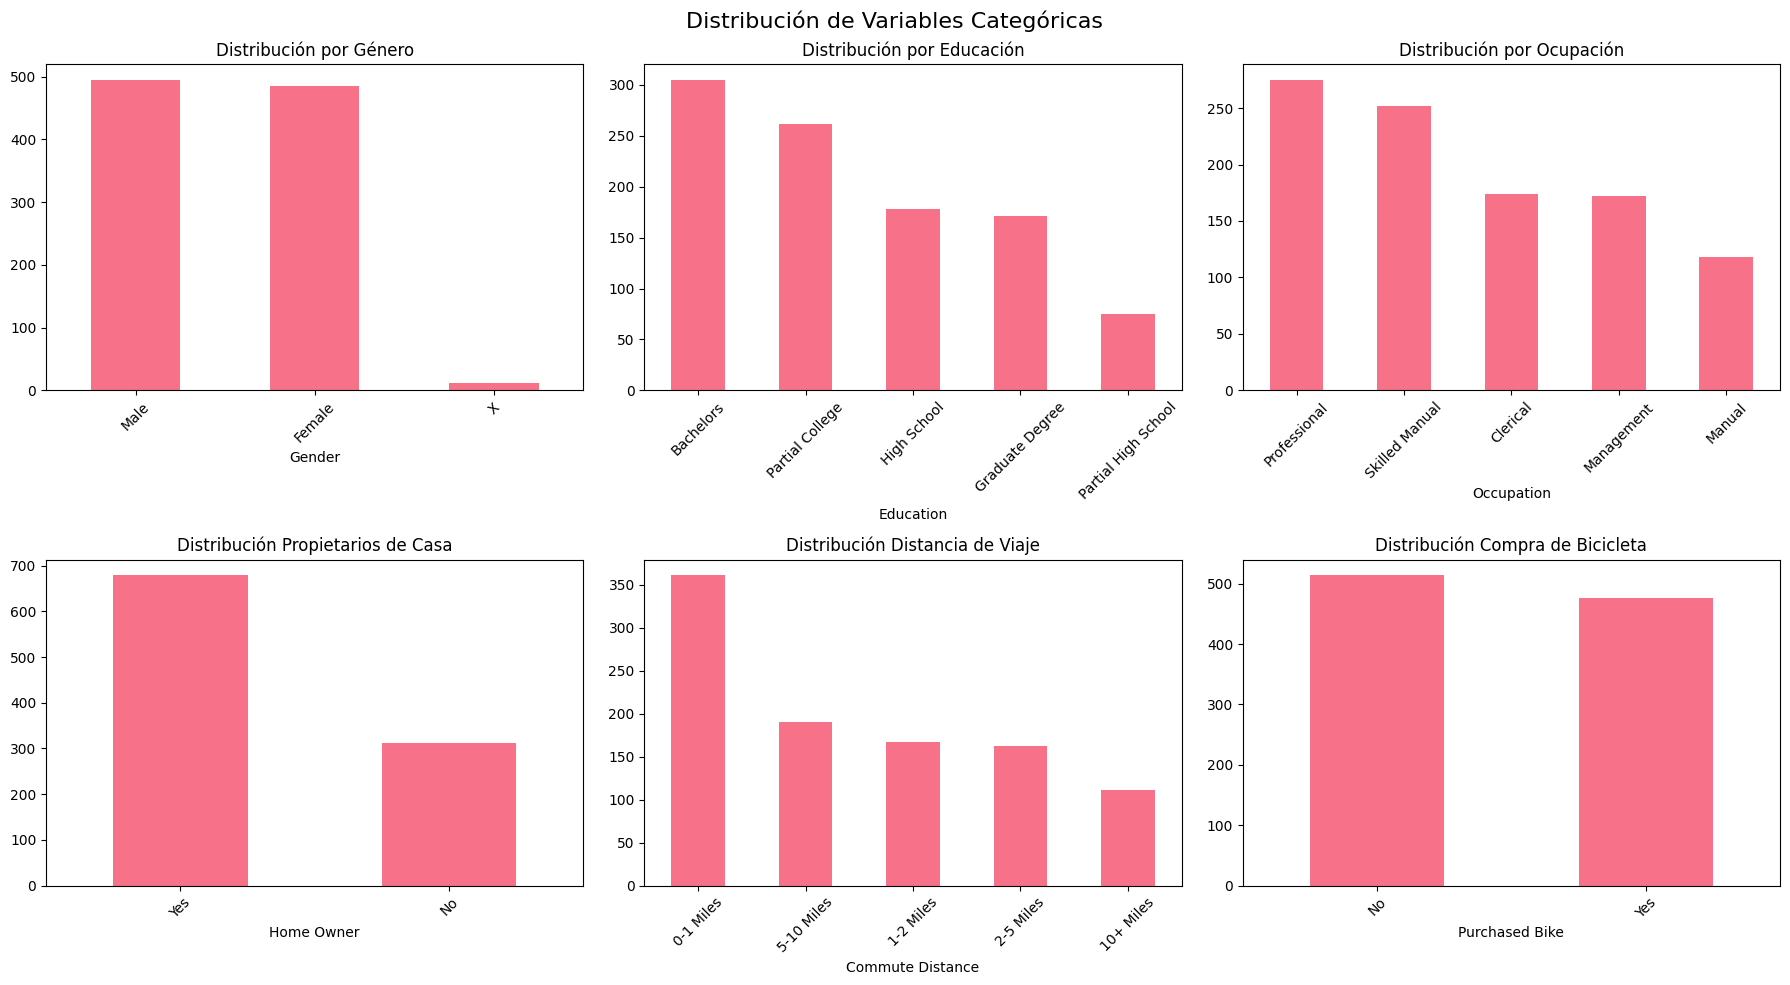

In [1133]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Distribución de Variables Categóricas', fontsize=16)

# Gender
bike_buyers['Gender'].value_counts().plot(kind='bar', ax=axes[0,0])
axes[0,0].set_title('Distribución por Género')
axes[0,0].tick_params(axis='x', rotation=45)

# Education
bike_buyers['Education'].value_counts().plot(kind='bar', ax=axes[0,1])
axes[0,1].set_title('Distribución por Educación')
axes[0,1].tick_params(axis='x', rotation=45)

# Occupation
bike_buyers['Occupation'].value_counts().plot(kind='bar', ax=axes[0,2])
axes[0,2].set_title('Distribución por Ocupación')
axes[0,2].tick_params(axis='x', rotation=45)

# Home Owner
bike_buyers['Home Owner'].value_counts().plot(kind='bar', ax=axes[1,0])
axes[1,0].set_title('Distribución Propietarios de Casa')
axes[1,0].tick_params(axis='x', rotation=45)

# Commute Distance
bike_buyers['Commute Distance'].value_counts().plot(kind='bar', ax=axes[1,1])
axes[1,1].set_title('Distribución Distancia de Viaje')
axes[1,1].tick_params(axis='x', rotation=45)

# Purchased Bike
bike_buyers['Purchased Bike'].value_counts().plot(kind='bar', ax=axes[1,2])
axes[1,2].set_title('Distribución Compra de Bicicleta')
axes[1,2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

### 4 - Análisis de Correlación

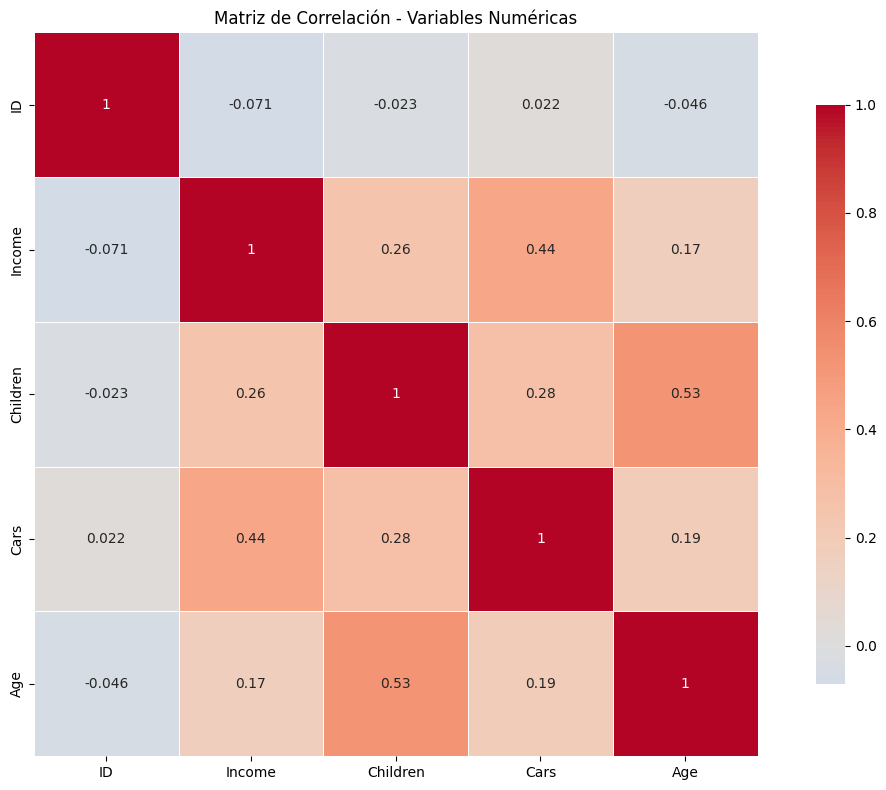

In [1134]:
plt.figure(figsize=(12, 8))
numeric_cols = bike_buyers.select_dtypes(include=[np.number]).columns
correlation_matrix = bike_buyers[numeric_cols].corr()

sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, square=True, linewidths=0.5, cbar_kws={"shrink": .8})
plt.title('Matriz de Correlación - Variables Numéricas')
plt.tight_layout()
plt.show()

### 5 - Análisis por segmentos (Purchased Bike vs otras variables)

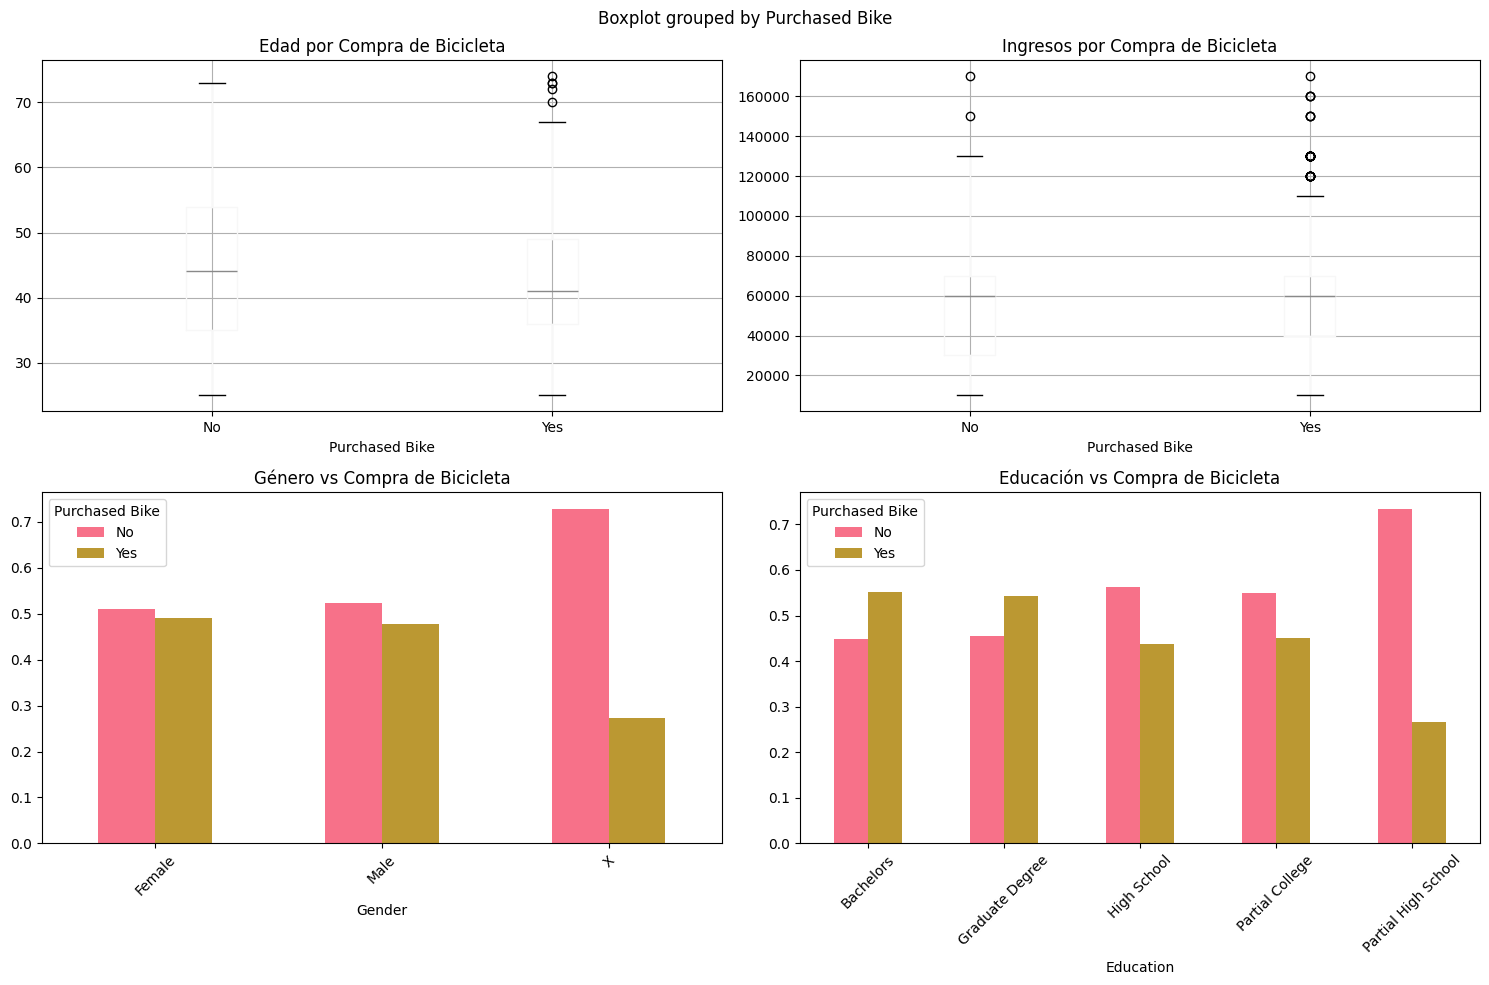

In [1135]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('Análisis por Segmento de Compra de Bicicleta', fontsize=16)

# Age vs Purchased Bike
bike_buyers.boxplot(column='Age', by='Purchased Bike', ax=axes[0,0])
axes[0,0].set_title('Edad por Compra de Bicicleta')

# Income vs Purchased Bike  
bike_buyers.boxplot(column='Income', by='Purchased Bike', ax=axes[0,1])
axes[0,1].set_title('Ingresos por Compra de Bicicleta')

# Gender vs Purchased Bike
pd.crosstab(bike_buyers['Gender'], bike_buyers['Purchased Bike'], normalize='index').plot(kind='bar', ax=axes[1,0])
axes[1,0].set_title('Género vs Compra de Bicicleta')
axes[1,0].tick_params(axis='x', rotation=45)

# Education vs Purchased Bike
pd.crosstab(bike_buyers['Education'], bike_buyers['Purchased Bike'], normalize='index').plot(kind='bar', ax=axes[1,1])
axes[1,1].set_title('Educación vs Compra de Bicicleta')
axes[1,1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

### 6 - Resumen final del dataset procesado

In [1136]:
print(f"Dimensiones finales: {bike_buyers.shape}")
print(f"Valores nulos totales: {bike_buyers.isnull().sum().sum()}")
print(f"\nTipos de datos:")
print(bike_buyers.dtypes.value_counts())

Dimensiones finales: (991, 23)
Valores nulos totales: 0

Tipos de datos:
bool       10
object      8
float64     4
int64       1
Name: count, dtype: int64


In [1137]:
print(f"Variables categóricas originales procesadas:")
print(f"- Gender: {bike_buyers['Gender'].nunique()} categorías")
print(f"- Education: Variables dummy creadas")
print(f"- Occupation: Variables dummy creadas")

Variables categóricas originales procesadas:
- Gender: 3 categorías
- Education: Variables dummy creadas
- Occupation: Variables dummy creadas
